In [367]:
import pandas as pd 
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt
import subprocess
import os 
sns.set_palette('colorblind')

In [240]:
import warnings
warnings.simplefilter(action='ignore',category=FutureWarning)

In [236]:
sns.color_palette('colorblind')

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [ ]:
project_dir = "/home/lorenzo/Documents/GENOMICS/PROJECT" ## replace with your path

In [143]:
metadata = pd.read_csv(project_dir+"/SGB1580_metadata.tsv",sep='\t')
metadata.head()

,magID,sampleID,sex,bmi,age,smoking_state,study_group
0,M1481385194,BP01023,male,24.691358,65,non-smoker,mucositis
1,M1320943765,BP01050,male,27.777778,64,smoker,periimplantitis
2,M1708806623,BP01100,female,19.031142,46,smoker,mucositis
3,M1048336460,BP02008,male,24.691358,73,smoker,periimplantitis
4,M1703261764,BP02036,female,20.761246,58,smoker,mucositis


/home/lorenzo/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/lorenzo/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


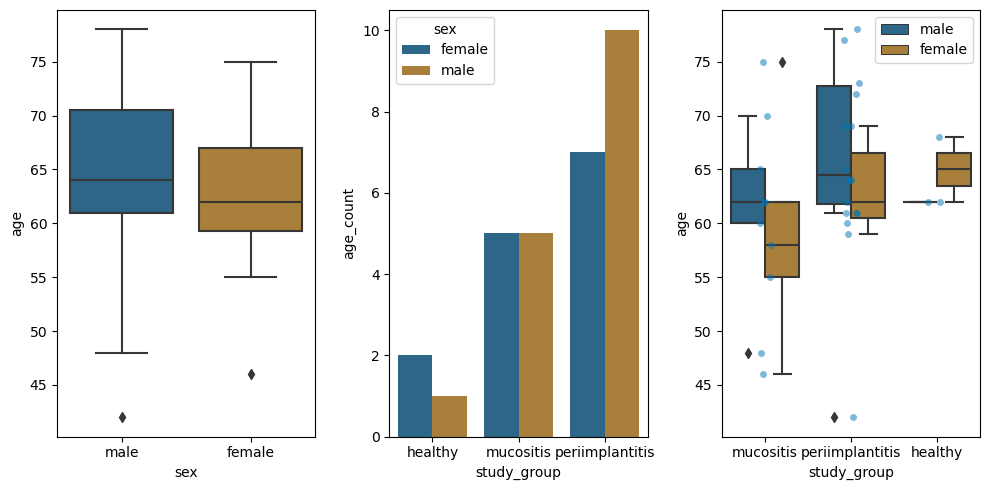

In [206]:
study_group_df = metadata.groupby(["study_group","sex"])["age"].count().to_frame(name="age_count")
study_group_df.reset_index(inplace=True)

fig,ax = plt.subplots(1,3,figsize=(10,5))
sns.boxplot(metadata,x='sex',y='age',saturation=0.5,ax=ax[0])
sns.barplot(data=study_group_df,x="study_group",y="age_count",hue="sex",saturation=0.5,ax=ax[1])
sns.boxplot(data=metadata, x="study_group",y="age",hue="sex",saturation=0.5,ax=ax[2])
sns.stripplot(data=metadata,x="study_group",y="age",alpha=0.5,ax=ax[2])

plt.tight_layout()

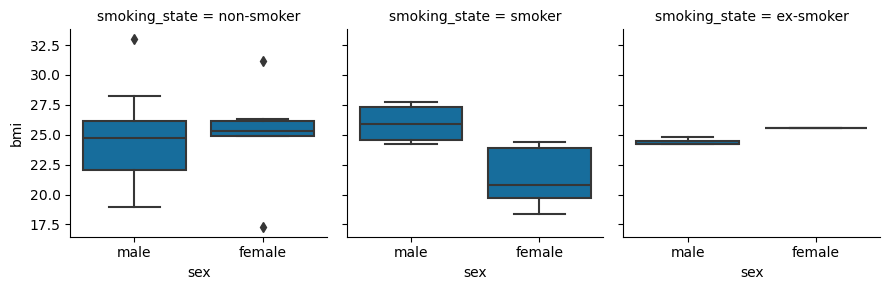

In [207]:
sns.FacetGrid(metadata,col="smoking_state").map_dataframe(sns.boxplot,x="sex",y="bmi")

# Checkm quality analysis

In [70]:
env = os.environ.copy()
env["MPLBACKEND"] = "Agg"
checkm_result = subprocess.run([
    'bash',
    '-c',
    f""" cd {project_dir}
        CONDA_BASE=$(conda info --base)
        source $CONDA_BASE/etc/profile.d/conda.sh
        mkdir -p checkm_output
        if [ ! -d "extracted_mags" ] || [ -z "$(ls -A "extracted_mags")" ]; then
            mkdir -p extracted_mags
            for bz2_file in mags/*.bz2
            do 
                filename=$( basename "$bz2_file" .bz2 )
                bunzip2 -c "$bz2_file" > extracted_mags/"$filename"
            done
        fi

        conda activate checkm
        checkm taxonomy_wf domain Bacteria extracted_mags checkm_output -t 4
    """
],env=env)

[2026-03-27 16:12:44] INFO: CheckM v1.2.5
[2026-03-27 16:12:44] INFO: checkm taxonomy_wf domain Bacteria extracted_mags checkm_output -t 4
[2026-03-27 16:12:44] INFO: CheckM data: /home/lorenzo/anaconda3/envs/checkm/checkm_data
[2026-03-27 16:12:44] INFO: [CheckM - taxon_set] Generate taxonomic-specific marker set.
[2026-03-27 16:12:47] INFO: Marker set for Bacteria contains 104 marker genes arranged in 58 sets.
[2026-03-27 16:12:47] INFO: Marker set inferred from 5449 reference genomes.
[2026-03-27 16:12:47] INFO: Marker set written to: checkm_output/Bacteria.ms
[2026-03-27 16:12:47] INFO: { Current stage: 0:00:03.282 || Total: 0:00:03.282 }
[2026-03-27 16:12:47] INFO: [CheckM - analyze] Identifying marker genes in bins.
[2026-03-27 16:12:47] INFO: Identifying marker genes in 30 bins with 4 threads:


    Finished processing 30 of 30 (100.00%) bins.


[2026-03-27 16:14:33] INFO: Saving HMM info to file.
[2026-03-27 16:14:33] INFO: { Current stage: 0:01:46.489 || Total: 0:01:49.772 }
[2026-03-27 16:14:33] INFO: Parsing HMM hits to marker genes:


    Finished parsing hits for 30 of 30 (100.00%) bins.


[2026-03-27 16:14:35] INFO: Aligning marker genes with multiple hits in a single bin:
[2026-03-27 16:14:35] INFO: { Current stage: 0:00:01.829 || Total: 0:01:51.601 }
[2026-03-27 16:14:35] INFO: Calculating genome statistics for 30 bins with 4 threads:


    Finished processing 30 of 30 (100.00%) bins.
    Finished processing 30 of 30 (100.00%) bins.


[2026-03-27 16:14:36] INFO: { Current stage: 0:00:00.405 || Total: 0:01:52.006 }
[2026-03-27 16:14:36] INFO: [CheckM - qa] Tabulating genome statistics.
[2026-03-27 16:14:36] INFO: Calculating AAI between multi-copy marker genes.
[2026-03-27 16:14:36] INFO: Reading HMM info from file.
[2026-03-27 16:14:36] INFO: Parsing HMM hits to marker genes:


----------------------------------------------------------------------------------------------------------------------------------------------------------
  Bin Id        Marker lineage   # genomes   # markers   # marker sets   0     1    2   3   4   5+   Completeness   Contamination   Strain heterogeneity  
----------------------------------------------------------------------------------------------------------------------------------------------------------
  M1927030333      Bacteria         5449        104            58        0    104   0   0   0   0       100.00           0.00               0.00          
  M1846526184      Bacteria         5449        104            58        0    104   0   0   0   0       100.00           0.00               0.00          
  M1702705864      Bacteria         5449        104            58        0    104   0   0   0   0       100.00           0.00               0.00          
  M1671123810      Bacteria         5449        104            58     

In [158]:
def get_col_names(df):
    colnames = []
    for key,_ in df.iloc[0].str.split(pat=':'):
        colnames.append(key.strip("{").strip(" '").strip("'").replace(" ","_").lower())
    return colnames

def get_value(x):
    x=x.split(':')
    return x[1].strip("'").strip(" '")

def quality_classifier(row):
    if row["completeness"] >= 50 and row["completeness"] < 90 and row["contamination"] < 5:
        return 'Medium' 
    elif row["completeness"] >= 90 and row["contamination"] < 5:
        return 'High'
    else :
        return 'Low'
def checkm_stats(path):
    checkmQC_table = pd.read_csv(path,sep='\t',header=None)
    features_complete = checkmQC_table[1].str.split(pat=',',expand=True)
    # predicted_genes = features_complete.iloc[:,27:]
    features = features_complete.iloc[:,:27]
    neat_features= features.applymap(get_value)
    neat_features.columns = get_col_names(features)
    neat_stats = pd.concat([checkmQC_table[0],neat_features],axis=1)
    neat_stats.rename(columns={0:'bin_ID'},inplace=True)
    neat_stats.sort_values(by=['completeness'],inplace=True)
    toconvert = neat_stats.iloc[:,2:].columns
    neat_stats[toconvert] = neat_stats[toconvert].apply(pd.to_numeric)
    neat_stats.sort_values(by=['completeness','contamination'],inplace=True,ascending=[False,True])
    neat_stats['bin_quality'] = neat_stats.apply(quality_classifier,axis=1)
    return neat_stats

neat_features = checkm_stats(project_dir+"/checkm_output/storage/bin_stats_ext.tsv")

neat_features.head()

/tmp/ipykernel_7739/1887708064.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  neat_features= features.applymap(get_value)


,bin_ID,marker_lineage,#_genomes,#_markers,#_marker_sets,0,1,2,3,4,...,longest_scaffold,longest_contig,n50_(scaffolds),n50_(contigs),mean_scaffold_length,mean_contig_length,coding_density,translation_table,#_predicted_genes,bin_quality
27,M1846526184,Bacteria,5449,104,58,0,104,0,0,0,...,253640,253640,98516,98516,46439.903846,46439.903846,0.882965,11,2079,High
18,M1702705864,Bacteria,5449,104,58,0,104,0,0,0,...,322473,322473,92645,92645,65076.236842,65076.236842,0.885269,11,2163,High
15,M1650726873,Bacteria,5449,104,58,0,104,0,0,0,...,381878,381878,103516,103516,73731.757576,73731.757576,0.886399,11,2152,High
13,M1548705285,Bacteria,5449,104,58,0,104,0,0,0,...,371733,371733,110801,110801,66763.111111,66763.111111,0.884498,11,2070,High
11,M1419890899,Bacteria,5449,104,58,0,104,0,0,0,...,231316,231316,91855,91855,47103.470588,47103.470588,0.882509,11,2086,High


In [185]:
neat_features.columns
## TODO meaninful plots 

Index(['bin_ID', 'marker_lineage', '#_genomes', '#_markers', '#_marker_sets',
       '0', '1', '2', '3', '4', '5+', 'completeness', 'contamination', 'gc',
       'gc_std', 'genome_size', '#_ambiguous_bases', '#_scaffolds',
       '#_contigs', 'longest_scaffold', 'longest_contig', 'n50_(scaffolds)',
       'n50_(contigs)', 'mean_scaffold_length', 'mean_contig_length',
       'coding_density', 'translation_table', '#_predicted_genes',
       'bin_quality'],
      dtype='object')

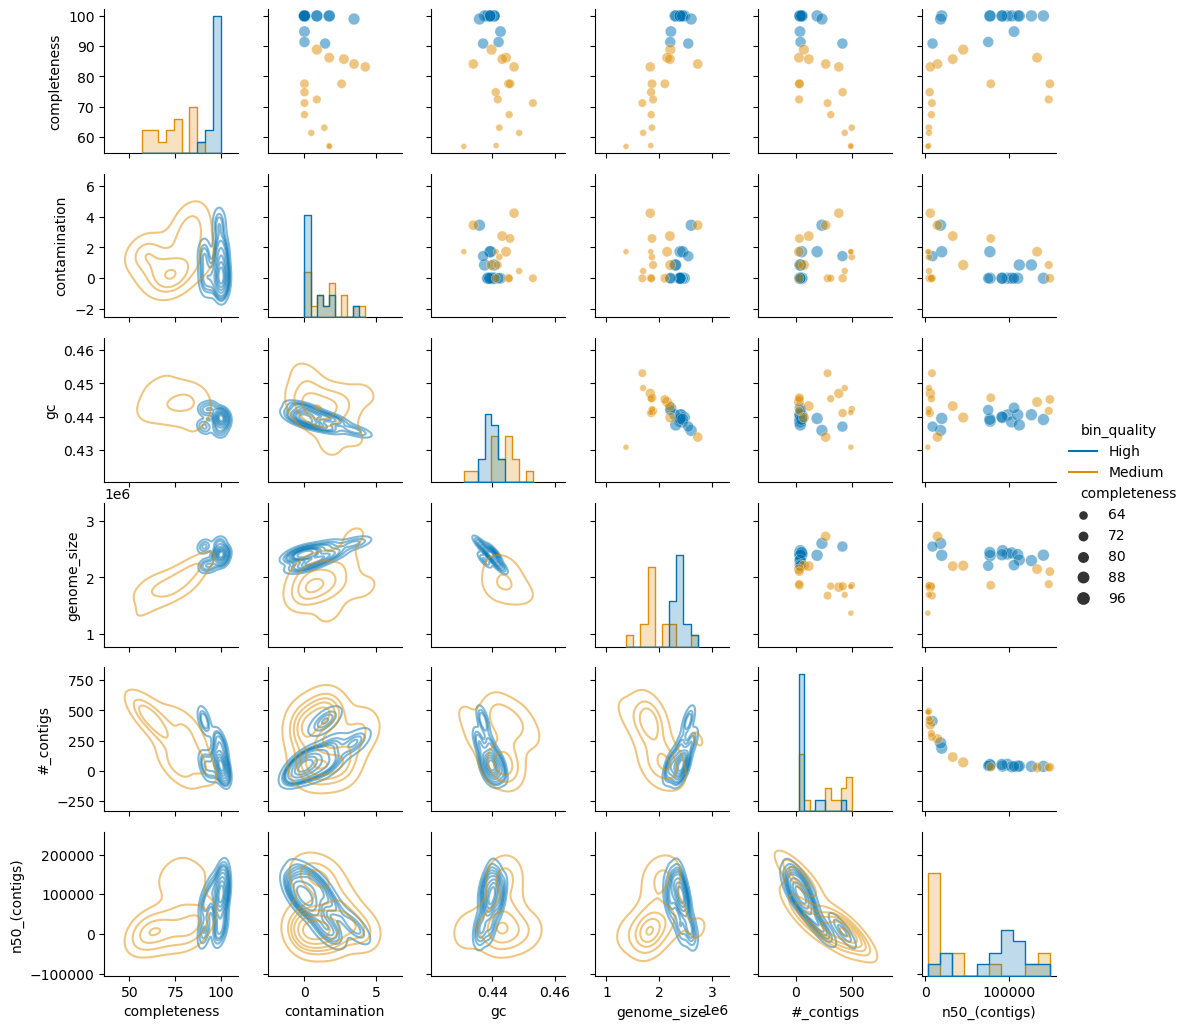

In [311]:
g=sns.PairGrid(neat_features.loc[:,['completeness', 'contamination', 'gc','genome_size','#_contigs', 'n50_(contigs)','bin_quality']],hue='bin_quality',palette='colorblind',height=1.75)
g.map_upper(sns.scatterplot,size=neat_features['completeness'],alpha=0.5)
g.map_diag(sns.histplot,element='step',bins=10)
g.map_lower(sns.kdeplot,alpha=0.5)
g.add_legend(title='',adjust_subtitles=True)

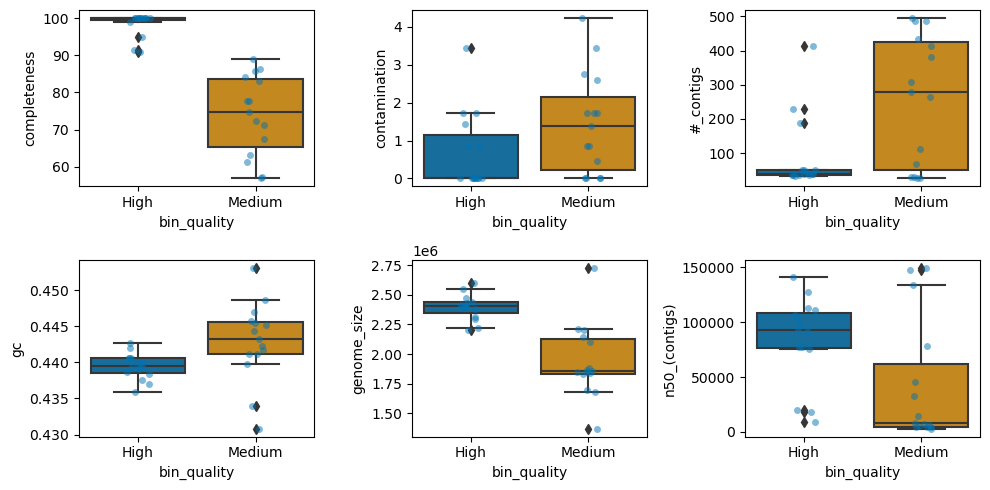

In [360]:
fig,ax=plt.subplots(2,3,figsize=(10,5))
cols = ['completeness','contamination','#_contigs', 'gc', 'genome_size', 'n50_(contigs)']
for i,name in enumerate(cols):
    sns.boxplot(neat_features,y=name,ax=ax[i//3,i%3],x='bin_quality')
    sns.stripplot(neat_features,x="bin_quality",y=name,alpha=0.5,ax=ax[i//3,i%3])
plt.tight_layout()

<Axes: xlabel='genome_size', ylabel='#_predicted_genes'>

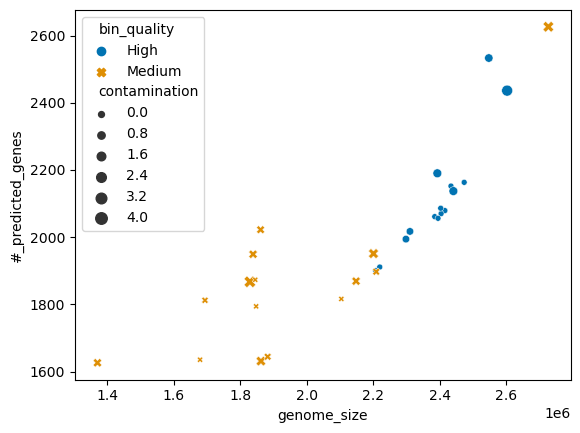

In [374]:
sns.scatterplot(neat_features,x='genome_size',y='#_predicted_genes',style='bin_quality',hue='bin_quality',size='contamination')


# Prokka annotations

In [ ]:
prokka_result = subprocess.run([
    'bash',
    '-c',
    f"""CONDA_BASE=$(conda info --base)
        source $CONDA_BASE/etc/profile.d/conda.sh
        conda activate prokka
        cd /home/lorenzo/Documents/GENOMICS/PROJECT
        ls
        if [ ! -d "extracted_mags" ] || [ ! -z "$(ls -A extracted_mags)" ]; then
            mkdir -p extracted_mags
            for bz2_file in mags/* .bz2
            do 
                filename=$( basename "$bz2_file" .bz2 )
                bunzip2 -c "$bz2_file" > extracted_mags/"$filename"
            done
        fi
        mkdir -p prokka_output
        # if [ -d "prokka_output" ] && [ ! -z "$(ls -A prokka_output)" ];then
        #     echo "clearing folder for re-analysis"
        #     rm -f prokka_output/*
        # fi

        for file in extracted_mags/*
        do
            echo "Running $file ..."
            mag=$( basename "$file" .fna )
            mkdir -p prokka_output/$mag
            prokka extracted_mags/"$mag".fna \
                --quiet \
		        --outdir prokka_output/"$mag" \
                --compliant \
		        --force \
		        --prefix "$mag" 2>&1 | tee prokka_output/$mag/prokka.log
        done
        conda deactivate

    """
],stdout=None,stderr=None)

extracted_mags
mags
proj_tmp.ipynb
prokka_output
SGB1580_metadata.tsv


bunzip2: Can't open input file .bz2: No such file or directory.


Running extracted_mags/M1025245651.fna ...
[14:31:19] This is prokka 1.14.6
[14:31:19] Written by Torsten Seemann <torsten.seemann@gmail.com>
[14:31:19] Homepage is https://github.com/tseemann/prokka
[14:31:19] Local time is Fri Mar 27 14:31:19 2026
[14:31:19] You are lorenzo
[14:31:19] Operating system is linux
[14:31:19] You have BioPerl 1.007002
[14:31:19] System has 8 cores.
[14:31:19] Will use maximum of 8 cores.
[14:31:19] Annotating as >>> Bacteria <<<
[14:31:19] Generating locus_tag from 'extracted_mags/M1025245651.fna' contents.
[14:31:19] Setting --locustag OPANPEBB from MD5 89a79ebb9cd37d93168e6042b35a575b
[14:31:19] Enabling options to ensure Genbank/ENA/DDJB submission compliance.
[14:31:19] Re-using existing --outdir prokka_output/M1025245651
[14:31:19] Using filename prefix: M1025245651.XXX
[14:31:19] Setting HMMER_NCPU=1
[14:31:19] Writing log to: prokka_output/M1025245651/M1025245651.log
[14:31:19] Command: /home/lorenzo/anaconda3/envs/prokka/bin/prokka extracted_mags/

In [403]:
def make_dataframe(path,ID):
    df = pd.read_csv(path,sep='\t')
    df = df.loc[df['ftype']=='CDS']
    df.insert(0,"bin_ID",ID)
    return df

def prokka_stats(path):
    df_list=[]
    for sub_dir in os.listdir(path+"/prokka_output"):
        ID = sub_dir
        for file in os.listdir(path+"/prokka_output/"+sub_dir):
            if file.endswith('.tsv'):
                df_list.append(make_dataframe(path+"/prokka_output/"+sub_dir+'/'+file,ID))

            else:
                continue
    CDSstats_df = pd.concat(df_list,ignore_index=True)
    return CDSstats_df
prokka_stats(project_dir)

,bin_ID,locus_tag,ftype,length_bp,gene,EC_number,COG,product
0,M1709480479,AAEJFGAO_00001,CDS,552,NaN,NaN,NaN,hypothetical protein
1,M1709480479,AAEJFGAO_00002,CDS,579,NaN,NaN,NaN,hypothetical protein
2,M1709480479,AAEJFGAO_00003,CDS,951,rgtE,2.4.1.-,COG0463,Dodecaprenyl-phosphate galacturonate synthase
3,M1709480479,AAEJFGAO_00004,CDS,486,NaN,NaN,NaN,hypothetical protein
4,M1709480479,AAEJFGAO_00005,CDS,684,NaN,NaN,NaN,hypothetical protein
...,...,...,...,...,...,...,...,...
55839,M1846526184,OFFJBEEN_02091,CDS,111,NaN,NaN,NaN,hypothetical protein
55840,M1846526184,OFFJBEEN_02092,CDS,1671,NaN,NaN,NaN,hypothetical protein
55841,M1846526184,OFFJBEEN_02093,CDS,1332,NaN,NaN,NaN,IS1380 family transposase ISDau1
55842,M1846526184,OFFJBEEN_02094,CDS,1026,NaN,NaN,NaN,hypothetical protein
